In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import preprocessing, tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score
from sklearn.preprocessing import LabelEncoder


In [74]:
df = pd.read_csv(
    filepath_or_buffer='data/drug200.csv'
)

In [75]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [92]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [76]:
df.shape

(200, 6)

In [77]:
df.columns


Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [78]:
df_uniques = pd.DataFrame(
    data=[[col, len(df[col].unique())]for col in df.columns],
    columns=['Feature Name', 'Uniqu Values Count']
).set_index('Feature Name')

df_uniques

,Uniqu Values Count
Feature Name,
Age,57
Sex,2
BP,3
Cholesterol,2
Na_to_K,198
Drug,5


In [79]:
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values

X[:5]

array([[23, 'F', 'HIGH', 'HIGH', 25.355],
       [47, 'M', 'LOW', 'HIGH', 13.093],
       [47, 'M', 'LOW', 'HIGH', 10.114],
       [28, 'F', 'NORMAL', 'HIGH', 7.798],
       [61, 'F', 'LOW', 'HIGH', 18.043]], dtype=object)

In [80]:
y =df['Drug']

y[:5]

0    DrugY
1    drugC
2    drugC
3    drugX
4    DrugY
Name: Drug, dtype: object

In [81]:
le_sex = LabelEncoder()
X[:,1] = le_sex.fit_transform(X[:,1])

le_bp = LabelEncoder()
X[:,2] = le_bp.fit_transform(X[:,2])

le_chol = LabelEncoder()
X[:,3] = le_chol.fit_transform(X[:,3])

X[:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [83]:
dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt = dt.fit(X_train, y_train)

dt.tree_.node_count, dt.tree_.max_depth

(11, 4)

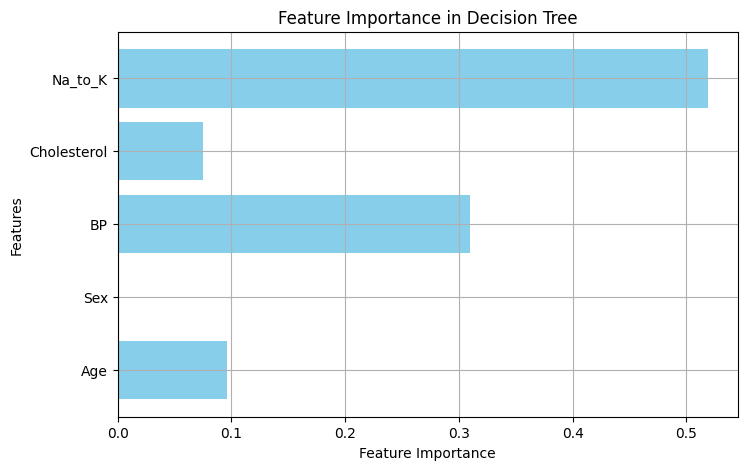

In [84]:
importance = dt.feature_importances_

feature_names = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']

plt.figure(figsize=(8,5))

plt.barh(feature_names, importance, color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Decision Tree')
plt.grid(True)
plt.show()

[Text(0.625, 0.9, 'Na_to_K <= 14.829\nentropy = 1.923\nsamples = 160\nvalue = [76, 17, 13, 11, 43]\nclass = DrugY'),
 Text(0.5, 0.7, 'BP <= 0.5\nentropy = 1.762\nsamples = 84\nvalue = [0, 17, 13, 11, 43]\nclass = drugX'),
 Text(0.5625, 0.8, 'True  '),
 Text(0.25, 0.5, 'Age <= 50.5\nentropy = 0.987\nsamples = 30\nvalue = [0, 17, 13, 0, 0]\nclass = drugA'),
 Text(0.125, 0.3, 'entropy = 0.0\nsamples = 17\nvalue = [0, 17, 0, 0, 0]\nclass = drugA'),
 Text(0.375, 0.3, 'entropy = 0.0\nsamples = 13\nvalue = [0, 0, 13, 0, 0]\nclass = drugB'),
 Text(0.75, 0.5, 'BP <= 1.5\nentropy = 0.729\nsamples = 54\nvalue = [0, 0, 0, 11, 43]\nclass = drugX'),
 Text(0.625, 0.3, 'Cholesterol <= 0.5\nentropy = 0.999\nsamples = 23\nvalue = [0, 0, 0, 11, 12]\nclass = drugX'),
 Text(0.5, 0.1, 'entropy = 0.0\nsamples = 11\nvalue = [0, 0, 0, 11, 0]\nclass = drugC'),
 Text(0.75, 0.1, 'entropy = 0.0\nsamples = 12\nvalue = [0, 0, 0, 0, 12]\nclass = drugX'),
 Text(0.875, 0.3, 'entropy = 0.0\nsamples = 31\nvalue = [0, 0, 

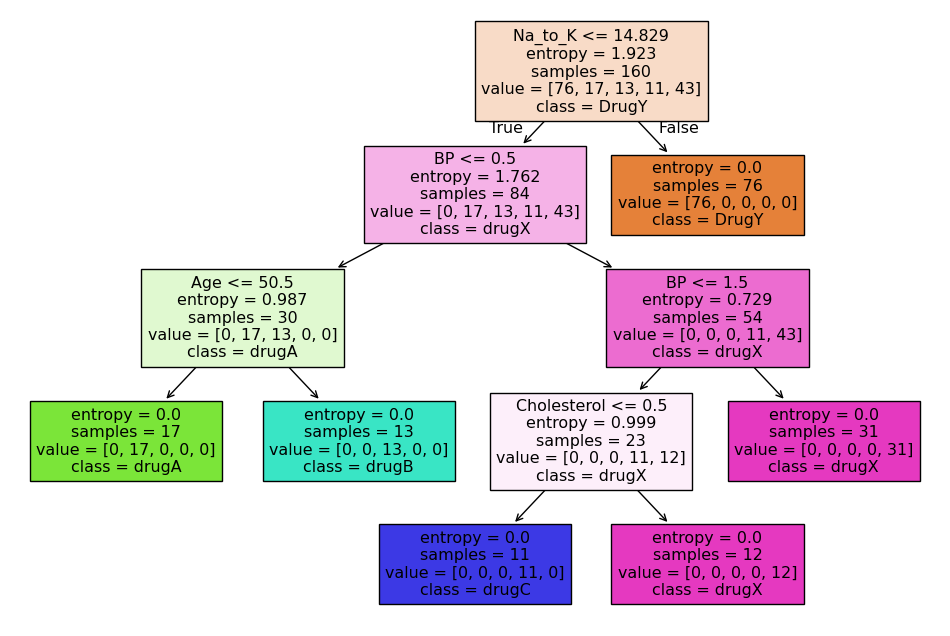

In [85]:
plt.figure(figsize=(12,8))
tree.plot_tree(
    decision_tree=dt,
    feature_names=feature_names,
    class_names=np.unique(y_train),
    filled=True
)

In [86]:
def measure_model(y_true, y_pred, dataset_name) -> pd.DataFrame:
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    return pd.DataFrame(
        {
            dataset_name: [acc, precision, recall, f1]
        },
        index=['Accuracy', 'Precision', 'Recall', 'F1 Score']
    )

In [87]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

train_test_full_evalute = pd.concat(
    [
        measure_model(y_train, y_train_pred, 'train'),
        measure_model(y_test, y_test_pred, 'test'),
    ],
    axis=1

)

train_test_full_evalute


,train,test
Accuracy,1.0,1.0
Precision,1.0,1.0
Recall,1.0,1.0
F1 Score,1.0,1.0


In [91]:
param_grid = {
    'max_depth': range(1, dt.tree_.max_depth + 1, 2),
    'max_features': range(1, len(dt.feature_importances_), + 1),
    
}
 
GR = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42,
        criterion='entropy'),
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=1
)

GR = GR.fit(X_train, y_train)

print(
    f'Calculated Number of Nodes: {GR.best_estimator_.tree_.node_count}\n'
    f'Max Depth: {GR.best_estimator_.tree_.max_depth}'
    f'{GR.best_estimator_.criterion}\n'
   
)

Calculated Number of Nodes: 9
Max Depth: 3entropy



In [89]:
y_train_pred_gr = GR.predict(X_train)
y_test_pred_gr = GR.predict(X_test)

gr_evalute = pd.concat(
    [
        measure_model(y_train, y_train_pred_gr, 'train'),
        measure_model(y_test, y_test_pred_gr, 'test')
    ],
    axis=1
)

gr_evalute

,train,test
Accuracy,0.931250,0.875000
Precision,0.759259,0.737500
Recall,0.800000,0.800000
F1 Score,0.777320,0.762963


In [93]:
dt_final = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3
)

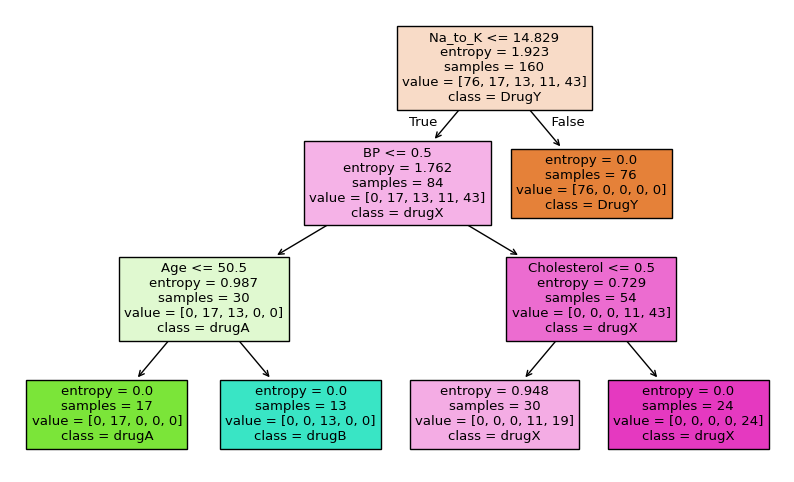

In [96]:
plt.figure(figsize=(10, 6))
tree.plot_tree(
    decision_tree=GR.best_estimator_,
    feature_names=feature_names,
    class_names=np.unique(y_train),
    filled=True
)
plt.show()

In [98]:
GR.best_estimator_.get_depth()
GR.best_estimator_.score(X_test, y_test)
print("Eski depth:", dt.get_depth())
print("Eski test score:", dt.score(X_test, y_test))

Eski depth: 4
Eski test score: 1.0
